# 04 - Introduction to CNNs

**Goal:** Understand how Convolutional Neural Networks "see" images.

---

## The Problem with Regular Neural Networks for Images

Remember from notebook 01: a regular neural network is just matrix multiplications.

For images, this has problems:

```
Image: 224 x 224 x 3 (RGB) = 150,528 pixels
First layer with 1000 neurons = 150,528 x 1000 = 150 million parameters!
```

That's just ONE layer. Problems:
1. **Too many parameters** → overfitting, slow training
2. **No spatial awareness** → pixel at (0,0) treated same as (100,100)
3. **Not translation invariant** → cat in top-left vs bottom-right looks completely different

## The Convolution Operation

A **convolution** slides a small filter (kernel) across the image:

```
Image (5x5):          Filter (3x3):         Output (3x3):
┌─────────────┐       ┌───────┐             
│ 1 2 3 4 5   │       │ 1 0 1 │             Each output pixel is
│ 2 3 4 5 6   │   *   │ 0 1 0 │      =      the sum of element-wise
│ 3 4 5 6 7   │       │ 1 0 1 │             multiplication
│ 4 5 6 7 8   │       └───────┘
│ 5 6 7 8 9   │
└─────────────┘
```

The **same filter** is applied everywhere → **parameter sharing** → way fewer parameters!

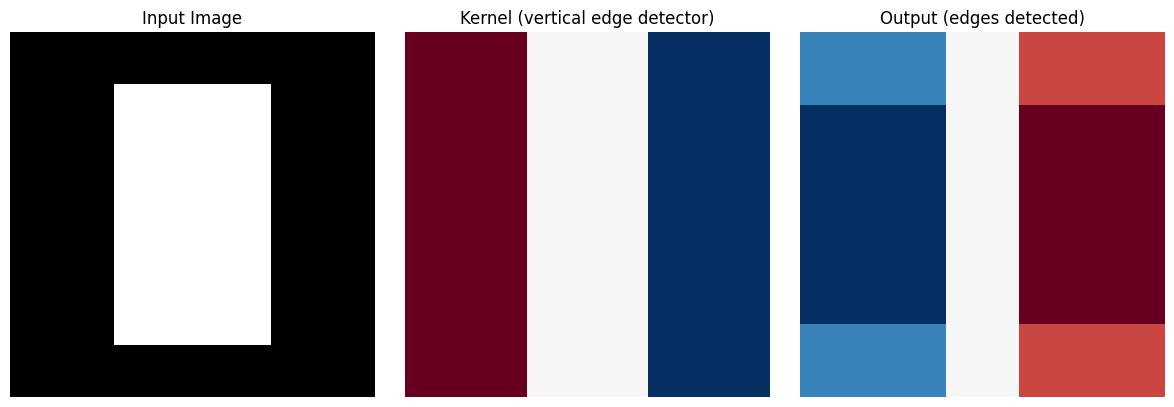

Left edge (negative), Right edge (positive)


In [1]:
import numpy as np
import matplotlib.pyplot as plt

def convolve2d(image, kernel):
    """Simple 2D convolution (no padding, stride=1)"""
    h, w = image.shape
    kh, kw = kernel.shape
    out_h, out_w = h - kh + 1, w - kw + 1
    output = np.zeros((out_h, out_w))
    
    for i in range(out_h):
        for j in range(out_w):
            # Extract patch and do element-wise multiplication
            patch = image[i:i+kh, j:j+kw]
            output[i, j] = np.sum(patch * kernel)
    
    return output

# Create a simple test image
image = np.array([
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 1, 1, 0, 0],
    [0, 0, 1, 1, 1, 0, 0],
    [0, 0, 1, 1, 1, 0, 0],
    [0, 0, 1, 1, 1, 0, 0],
    [0, 0, 1, 1, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
], dtype=float)

# Edge detection filter (vertical edges)
vertical_edge_kernel = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
])

# Apply convolution
output = convolve2d(image, vertical_edge_kernel)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(image, cmap='gray')
axes[0].set_title('Input Image')

axes[1].imshow(vertical_edge_kernel, cmap='RdBu')
axes[1].set_title('Kernel (vertical edge detector)')

axes[2].imshow(output, cmap='RdBu')
axes[2].set_title('Output (edges detected)')

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

print("Left edge (negative), Right edge (positive)")

## Key Properties of Convolutions

### 1. Parameter Sharing
Same filter weights used everywhere → fewer parameters

```
Regular layer for 224x224 image with 64 outputs: 150,528 × 64 = 9.6M parameters
Conv layer with 64 filters of 3x3: 3 × 3 × 64 = 576 parameters!
```

### 2. Translation Equivariance
If the input shifts, the output shifts the same way. A cat is a cat regardless of position.

### 3. Local Connectivity
Each output only depends on a small region (receptive field) of the input.

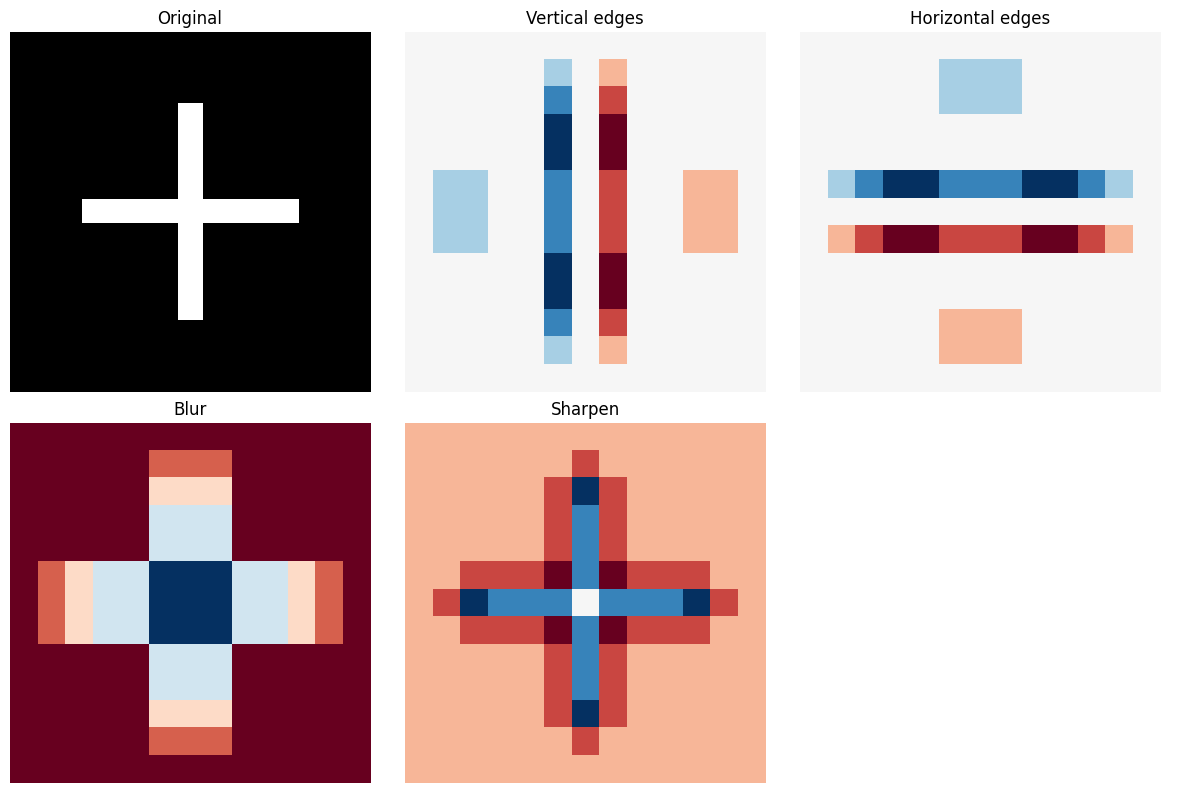

In [2]:
# Different filters detect different features

# Create a more interesting test pattern
image = np.zeros((15, 15))
image[3:12, 7] = 1  # Vertical line
image[7, 3:12] = 1  # Horizontal line

# Different kernels
kernels = {
    'Vertical edges': np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]]),
    'Horizontal edges': np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]]),
    'Blur': np.ones((3, 3)) / 9,
    'Sharpen': np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]]),
}

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

axes[0, 0].imshow(image, cmap='gray')
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')

axes[0, 1].axis('off')  # Empty
axes[0, 2].axis('off')  # Empty

for idx, (name, kernel) in enumerate(kernels.items()):
    row, col = (idx // 3) + 1, idx % 3
    if row == 1:
        row, col = 0, idx + 1
    if idx < 2:
        ax = axes[0, idx + 1]
    else:
        ax = axes[1, idx - 2]
    
    output = convolve2d(image, kernel)
    ax.imshow(output, cmap='RdBu')
    ax.set_title(name)
    ax.axis('off')

axes[1, 2].axis('off')
plt.tight_layout()
plt.show()

## Learned Filters

The key insight: **we don't design the filters, we learn them!**

- Early layers learn simple features (edges, colors, textures)
- Middle layers combine these into patterns (corners, circles, shapes)
- Deep layers recognize high-level concepts (eyes, wheels, vertebrae)

The filter values are the **weights** that get trained.

In [3]:
import torch
import torch.nn as nn

# A convolutional layer in PyTorch
conv_layer = nn.Conv2d(
    in_channels=1,    # Grayscale input
    out_channels=16,  # 16 different filters
    kernel_size=3,    # 3x3 filters
    padding=1         # Keep same spatial size
)

print(f"Number of filters: {conv_layer.out_channels}")
print(f"Filter size: {conv_layer.kernel_size}")
print(f"Total parameters: {sum(p.numel() for p in conv_layer.parameters())}")
print(f"  - Weights: {conv_layer.weight.shape} = {conv_layer.weight.numel()}")
print(f"  - Biases: {conv_layer.bias.shape} = {conv_layer.bias.numel()}")

Number of filters: 16
Filter size: (3, 3)
Total parameters: 160
  - Weights: torch.Size([16, 1, 3, 3]) = 144
  - Biases: torch.Size([16]) = 16


## CNN Building Blocks

A CNN typically stacks these operations:

### 1. Convolution
Extract features using learned filters

### 2. Activation (ReLU)
Add non-linearity: `max(0, x)`

### 3. Pooling
Reduce spatial size, keep important features

```
Max Pooling 2x2:
┌─────┬─────┐     ┌───┐
│ 1 3 │ 2 1 │     │ 3 │ 2 │    Take max from each 2x2 region
│ 2 1 │ 1 2 │  →  └───┴───┘
├─────┼─────┤     │ 4 │ 3 │
│ 4 2 │ 3 1 │     └───┴───┘
│ 1 1 │ 2 3 │
└─────┴─────┘
```

In [4]:
# A simple CNN in PyTorch

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Convolutional layers
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)   # 1 channel in, 32 out
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # 32 in, 64 out
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, padding=1)  # 64 in, 64 out
        
        self.pool = nn.MaxPool2d(2, 2)  # Halve spatial dimensions
        self.relu = nn.ReLU()
        
        # Final classification layer (for 28x28 input like MNIST)
        # After 3 pooling: 28 -> 14 -> 7 -> 3 (with floor)
        self.fc = nn.Linear(64 * 3 * 3, 10)  # 10 digit classes
    
    def forward(self, x):
        # Conv block 1
        x = self.relu(self.conv1(x))
        x = self.pool(x)
        
        # Conv block 2
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        
        # Conv block 3
        x = self.relu(self.conv3(x))
        x = self.pool(x)
        
        # Flatten and classify
        x = x.view(x.size(0), -1)  # Flatten
        x = self.fc(x)
        
        return x

# Create model and show architecture
model = SimpleCNN()
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (fc): Linear(in_features=576, out_features=10, bias=True)
)

Total parameters: 61,514


In [5]:
# Trace the shape through the network

x = torch.randn(1, 1, 28, 28)  # Batch of 1, 1 channel, 28x28 image
print(f"Input: {x.shape}")

# Manual forward pass to see shapes
x = model.relu(model.conv1(x))
print(f"After conv1: {x.shape}")
x = model.pool(x)
print(f"After pool1: {x.shape}")

x = model.relu(model.conv2(x))
print(f"After conv2: {x.shape}")
x = model.pool(x)
print(f"After pool2: {x.shape}")

x = model.relu(model.conv3(x))
print(f"After conv3: {x.shape}")
x = model.pool(x)
print(f"After pool3: {x.shape}")

x = x.view(x.size(0), -1)
print(f"After flatten: {x.shape}")

x = model.fc(x)
print(f"Output: {x.shape}")

Input: torch.Size([1, 1, 28, 28])
After conv1: torch.Size([1, 32, 28, 28])
After pool1: torch.Size([1, 32, 14, 14])
After conv2: torch.Size([1, 64, 14, 14])
After pool2: torch.Size([1, 64, 7, 7])
After conv3: torch.Size([1, 64, 7, 7])
After pool3: torch.Size([1, 64, 3, 3])
After flatten: torch.Size([1, 576])
Output: torch.Size([1, 10])


## 3D Convolutions (Your Use Case)

For volumetric data (CT scans), we use **3D convolutions**:

```
2D Conv: kernel slides over height × width
3D Conv: kernel slides over depth × height × width
```

Your production code processes 3D volumes:
- Input: `(batch, channels, depth, height, width)` = `(1, 1, 96, 96, 96)`
- 3D convolutions preserve spatial relationships in all three dimensions

In [6]:
# 3D convolution example

conv3d = nn.Conv3d(
    in_channels=1,
    out_channels=24,   # SwinUNETR uses feature_size=24
    kernel_size=3,
    padding=1
)

# Simulate input like your production model
volume = torch.randn(1, 1, 96, 96, 96)  # Batch=1, Channels=1, 96x96x96 volume
output = conv3d(volume)

print(f"Input shape: {volume.shape}")
print(f"Output shape: {output.shape}")
print(f"Parameters: {sum(p.numel() for p in conv3d.parameters()):,}")

Input shape: torch.Size([1, 1, 96, 96, 96])
Output shape: torch.Size([1, 24, 96, 96, 96])
Parameters: 672


## From Classification to Segmentation

**Classification CNN:**
```
Image → Conv → Pool → Conv → Pool → Flatten → Dense → Class label
                                                        (one output)
```

**Segmentation CNN (U-Net):**
```
Image → Conv → Pool → Conv → Pool → Upsample → Conv → Upsample → Pixel labels
         ↓              ↓              ↑              ↑           (same size as input)
         └──────────────┴──────────────┴──────────────┘
                      Skip connections
```

Segmentation needs to output the **same spatial size** as input (one class per pixel).

We'll dive deep into U-Net in Phase 2.

## Summary

| Concept | What it means |
|---------|---------------|
| **Convolution** | Slide a filter across the image, detect local patterns |
| **Filter/Kernel** | Small matrix of learnable weights (e.g., 3×3) |
| **Feature Map** | Output of applying a filter (highlights certain features) |
| **Pooling** | Downsample to reduce size, keep important info |
| **Receptive Field** | Region of input that affects one output pixel |
| **3D Conv** | Same concept but for volumetric data (CT scans) |

**Key insight:** CNNs learn hierarchical features automatically:
- Layer 1: edges, colors
- Layer 2: textures, corners
- Layer 3+: shapes, parts, objects

---

## Phase 0 Complete!

You now understand:
1. What neural networks are (weighted sums + activations)
2. How they learn (loss functions, backpropagation)
3. Why GPUs matter (parallel matrix math)
4. How CNNs work (convolutions, pooling, learned filters)

**Next: Phase 1** - Hands-on PyTorch. We'll build and train these concepts yourself.